In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

tile_size = 80
patch_spacing = 4000
tiles_root = Path(r"processed/TILES")

catalog = pd.read_parquet(r"processed/cleaned_catalog_with_split.parquet")

def parse_tile_coords(filename_stem):
    match = re.search(r"_x(\d+)_y(\d+)$", filename_stem)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None

records = []
unparsed = []

for tier_folder in tiles_root.iterdir():
    if not tier_folder.is_dir():
        continue
    tier_name = tier_folder.name

    for patch_folder in tier_folder.iterdir():
        if not patch_folder.is_dir():
            continue
        patch_id = patch_folder.name

        patch_col, patch_row = map(int, patch_id.split(","))
        x_offset = patch_col * patch_spacing
        y_offset = patch_row * patch_spacing

        patch_cat = catalog[catalog["patch_meas"] == patch_id].copy()
        if len(patch_cat) == 0:
            continue

        x_coords = patch_cat["x"].values - x_offset
        y_coords = patch_cat["y"].values - y_offset
        patch_cat = patch_cat.assign(x_local=x_coords, y_local=y_coords)

        for tile_file in patch_folder.glob("*.npy"):
            coords = parse_tile_coords(tile_file.stem)
            if coords is None:
                unparsed.append(str(tile_file))
                continue
            x_min, y_min = coords
            x_max, y_max = x_min + tile_size, y_min + tile_size

            mask = (
                (patch_cat["x_local"] >= x_min) & (patch_cat["x_local"] < x_max) &
                (patch_cat["y_local"] >= y_min) & (patch_cat["y_local"] < y_max)
            )
            objs_in_tile = patch_cat[mask]
            if len(objs_in_tile) == 0:
                continue

            target = objs_in_tile.loc[objs_in_tile["flux_r"].idxmax()]

            records.append({
                "tile_path": str(tile_file),
                "patch_id": patch_id,
                "tier": tier_name,
                "n_objects_in_tile": len(objs_in_tile),
                "target_objectId": target["objectId"],
                "target_flux_r_true": target["flux_r"],
                "target_flux_u_true": target["flux_u"],
                "target_flux_g_true": target["flux_g"],
                "target_flux_i_true": target["flux_i"],
                "target_flux_z_true": target["flux_z"],
                "target_flux_y_true": target["flux_y"],
                "target_x_local": target["x_local"],
                "target_y_local": target["y_local"],
            })

tile_targets = pd.DataFrame(records)
print(f"Tiles mapped: {len(tile_targets)}")
print(f"Unparseable: {len(unparsed)}")
print(f"Tiles with >1 object (blended): {(tile_targets['n_objects_in_tile'] > 1).sum()} "
      f"({100*(tile_targets['n_objects_in_tile'] > 1).mean():.1f}%)")

manifest = pd.read_parquet(r"processed/tile_manifest.parquet")
manifest_with_truth = manifest.merge(
    tile_targets.drop(columns=["tier"]), on="tile_path", how="left"
)

out_path = Path("processed/tile_manifest_with_truth.parquet")
manifest_with_truth.to_parquet(out_path)
print(f"\nSaved: {out_path}")
print(f"Matched: {manifest_with_truth['target_objectId'].notna().sum()} / {len(manifest_with_truth)}")

Tiles mapped: 18695
Unparseable: 0
Tiles with >1 object (blended): 9306 (49.8%)

Saved: processed\tile_manifest_with_truth.parquet
Matched: 18695 / 18695


Clean single-object tiles available: 9389

Tiles used for calibration: 500
Pixel-sum / true-flux ratio (r-band):
  mean:   0.440452
  median: 0.0475613
  std:    2.41345
  CV (std/mean): 5.479


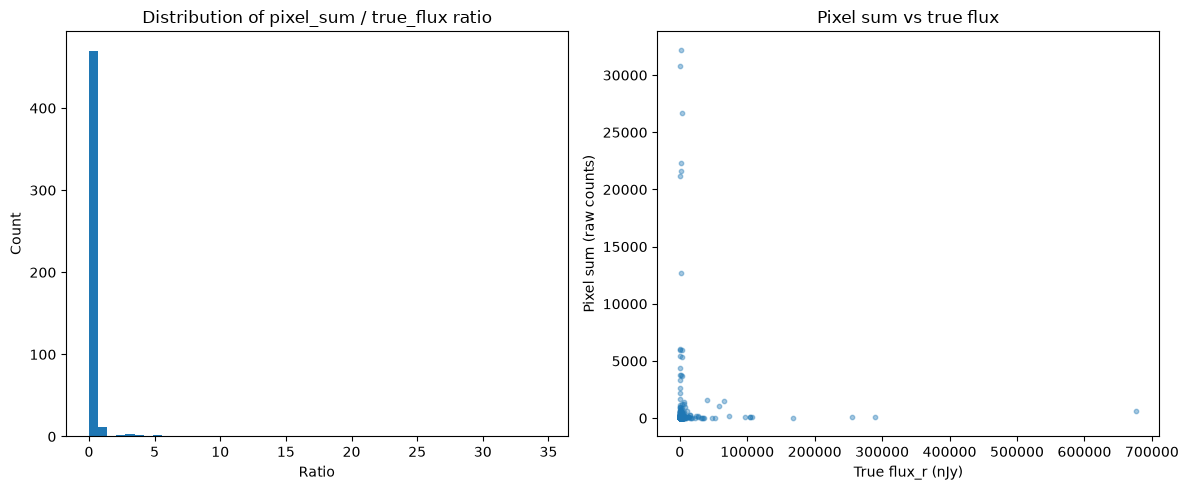


Derived scale factor (counts -> nJy): 21.0255
i.e. flux_nJy ≈ pixel_value * 21.0255

⚠️ CV = 5.479 — ratio is NOT tightly consistent. Investigate before trusting this scale factor (per-patch zero-point variation, aperture vs. total flux mismatch, or tile-matching issues).

Saved scale factor to processed/flux_scale_factor.txt


In [2]:
"""
FLUX CALIBRATION NOTEBOOK
==========================

PURPOSE:
Raw calexp FITS pixel values in this dataset are in instrumental counts
(ADU), NOT physically calibrated flux units. The LSST Science Pipelines
normally apply a PhotoCalib correction to convert counts -> nanojanskys
(nJy), but that calibration is stored as a serialized 'archive' object
inside the FITS file (HIERARCH PHOTOCALIB_ID etc.), which requires the
full LSST Science Pipelines software stack (lsst.afw.image) to decode --
not accessible via plain astropy.io.fits, and not practical to install
given this project's timeline.

The DC2 truth catalog (truth_tract3828.parquet) reports true galaxy flux
in nanojanskys (flux_u, flux_g, flux_r, flux_i, flux_z, flux_y) -- see
LSST/DP0 docs: all flux units are nJy, mAB = -2.5*log10(f_nJy) + 31.4.

To compare model outputs (all trained on raw-count tiles) against this
truth, an EMPIRICAL scale factor is derived here instead: using clean,
single-object tiles (no blending ambiguity), we compute the ratio of
summed pixel counts to true flux_r, and check whether that ratio is
consistent across many independent tiles. If so, its reciprocal is a
valid global counts -> nJy conversion factor for this dataset.

USAGE DOWNSTREAM:
    flux_nJy ≈ pixel_value * scale_factor

This factor applies identically to any model operating on these same
raw tiles (VAE/debvader, BLISS, U-Net, CNN/RDN). SCARLET is the one
exception -- its outputs come from object_dpdd (e.g. cModelFlux),
which are already pipeline-calibrated in nJy, so no correction is
needed there.

OUTPUT:
    processed/flux_scale_factor.txt   -- the derived scalar
    processed/flux_calibration_check.png  -- diagnostic plots
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD TILE -> TRUTH MAPPING
# ============================================================
tile_targets = pd.read_parquet(r"processed/tile_manifest_with_truth.parquet")

# ============================================================
# ISOLATE CLEAN SINGLE-OBJECT TILES (unambiguous flux check)
# ============================================================
clean = tile_targets[tile_targets["n_objects_in_tile"] == 1].copy()
print(f"Clean single-object tiles available: {len(clean)}")

sample = clean.sample(n=min(500, len(clean)), random_state=42)

# ============================================================
# COMPUTE PIXEL-SUM / TRUE-FLUX RATIO PER TILE (r-band)
# ============================================================
r_band_index = 2  # bands = ['u','g','r','i','z','y'] -> r is index 2

records = []
for _, row in sample.iterrows():
    arr = np.load(row["tile_path"])  # channel-first (6, 80, 80)
    pixel_sum_r = arr[r_band_index].sum()
    true_flux_r = row["target_flux_r_true"]
    if true_flux_r > 0 and pixel_sum_r > 0:
        records.append({
            "tile_path": row["tile_path"],
            "tier": row["tier"],
            "pixel_sum_r": pixel_sum_r,
            "true_flux_r": true_flux_r,
            "ratio": pixel_sum_r / true_flux_r,
        })

calib_df = pd.DataFrame(records)
ratios = calib_df["ratio"].values

print(f"\nTiles used for calibration: {len(calib_df)}")
print(f"Pixel-sum / true-flux ratio (r-band):")
print(f"  mean:   {ratios.mean():.6g}")
print(f"  median: {np.median(ratios):.6g}")
print(f"  std:    {ratios.std():.6g}")
print(f"  CV (std/mean): {ratios.std()/ratios.mean():.3f}")

# ============================================================
# VISUAL CHECK — is the ratio actually consistent?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ratios, bins=50)
axes[0].set_title("Distribution of pixel_sum / true_flux ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Count")

axes[1].scatter(calib_df["true_flux_r"], calib_df["pixel_sum_r"], alpha=0.4, s=10)
axes[1].set_xlabel("True flux_r (nJy)")
axes[1].set_ylabel("Pixel sum (raw counts)")
axes[1].set_title("Pixel sum vs true flux")
plt.tight_layout()
plt.savefig("processed/flux_calibration_check.png", dpi=150)
plt.show()

# ============================================================
# DERIVE THE SCALE FACTOR (if ratio is consistent)
# ============================================================
scale_factor = 1.0 / np.median(ratios)
cv = ratios.std() / ratios.mean()

print(f"\nDerived scale factor (counts -> nJy): {scale_factor:.6g}")
print(f"i.e. flux_nJy ≈ pixel_value * {scale_factor:.6g}")

if cv < 0.20:
    print(f"\n✅ CV = {cv:.3f} — ratio is consistent enough to trust as a global scale factor.")
else:
    print(f"\n⚠️ CV = {cv:.3f} — ratio is NOT tightly consistent. "
          f"Investigate before trusting this scale factor (per-patch zero-point "
          f"variation, aperture vs. total flux mismatch, or tile-matching issues).")

# Save it for reuse across all models
with open("processed/flux_scale_factor.txt", "w") as f:
    f.write(str(scale_factor))

print(f"\nSaved scale factor to processed/flux_scale_factor.txt")

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIG (same as your tiling script)
# ============================================================
tile_size = 80
patch_spacing = 4000
tiles_root = Path(r"processed/TILES")

catalog = pd.read_parquet(r"processed/cleaned_catalog_with_split.parquet")

# ============================================================
# REBUILD TILE -> OBJECT(S) MAPPING
# ============================================================
records = []

for tier_folder in tiles_root.iterdir():
    if not tier_folder.is_dir():
        continue
    tier_name = tier_folder.name  # HIGH / MEAN / LOW

    for patch_folder in tier_folder.iterdir():
        if not patch_folder.is_dir():
            continue
        patch_id = patch_folder.name  # e.g. "0,4"

        patch_col, patch_row = map(int, patch_id.split(","))
        x_offset = patch_col * patch_spacing
        y_offset = patch_row * patch_spacing

        patch_cat = catalog[catalog["patch_meas"] == patch_id].copy()
        if len(patch_cat) == 0:
            continue

        x_coords = patch_cat["x"].values - x_offset
        y_coords = patch_cat["y"].values - y_offset
        patch_cat = patch_cat.assign(x_local=x_coords, y_local=y_coords)

        for tile_file in patch_folder.glob("*.npy"):
            stem = tile_file.stem  # "tile_x123_y456"
            parts = stem.replace("tile_x", "").split("_y")
            x_min, y_min = int(parts[0]), int(parts[1])
            x_max, y_max = x_min + tile_size, y_min + tile_size

            mask = (
                (patch_cat["x_local"] >= x_min) & (patch_cat["x_local"] < x_max) &
                (patch_cat["y_local"] >= y_min) & (patch_cat["y_local"] < y_max)
            )
            objs_in_tile = patch_cat[mask]

            if len(objs_in_tile) == 0:
                continue

            target = objs_in_tile.loc[objs_in_tile["flux_r"].idxmax()]

            records.append({
                "tile_path": str(tile_file),
                "patch_id": patch_id,
                "tier": tier_name,
                "n_objects_in_tile": len(objs_in_tile),
                "target_objectId": target["objectId"],
                "target_flux_r_true": target["flux_r"],
                "target_flux_u_true": target["flux_u"],
                "target_flux_g_true": target["flux_g"],
                "target_flux_i_true": target["flux_i"],
                "target_flux_z_true": target["flux_z"],
                "target_flux_y_true": target["flux_y"],
                "target_x_local": target["x_local"],
                "target_y_local": target["y_local"],
            })

tile_targets = pd.DataFrame(records)
print(f"Tiles mapped: {len(tile_targets)}")
print(f"Tiles with >1 object (genuinely blended tiles): "
      f"{(tile_targets['n_objects_in_tile'] > 1).sum()} "
      f"({100*(tile_targets['n_objects_in_tile'] > 1).mean():.1f}%)")

# Merge onto your existing tile_manifest so tier/split/tile_path_tf all line up
manifest = pd.read_parquet(r"processed/tile_manifest.parquet")
manifest_with_truth = manifest.merge(
    tile_targets.drop(columns=["tier"]),
    on="tile_path", how="left"
)

out_path = Path("processed/tile_manifest_with_truth.parquet")
manifest_with_truth.to_parquet(out_path)
print(f"\nSaved: {out_path}")
print(f"Tiles successfully matched to a target galaxy: "
      f"{manifest_with_truth['target_objectId'].notna().sum()} / {len(manifest_with_truth)}")

ValueError: invalid literal for int() with base 10: 'tile_obj_0_x1021'

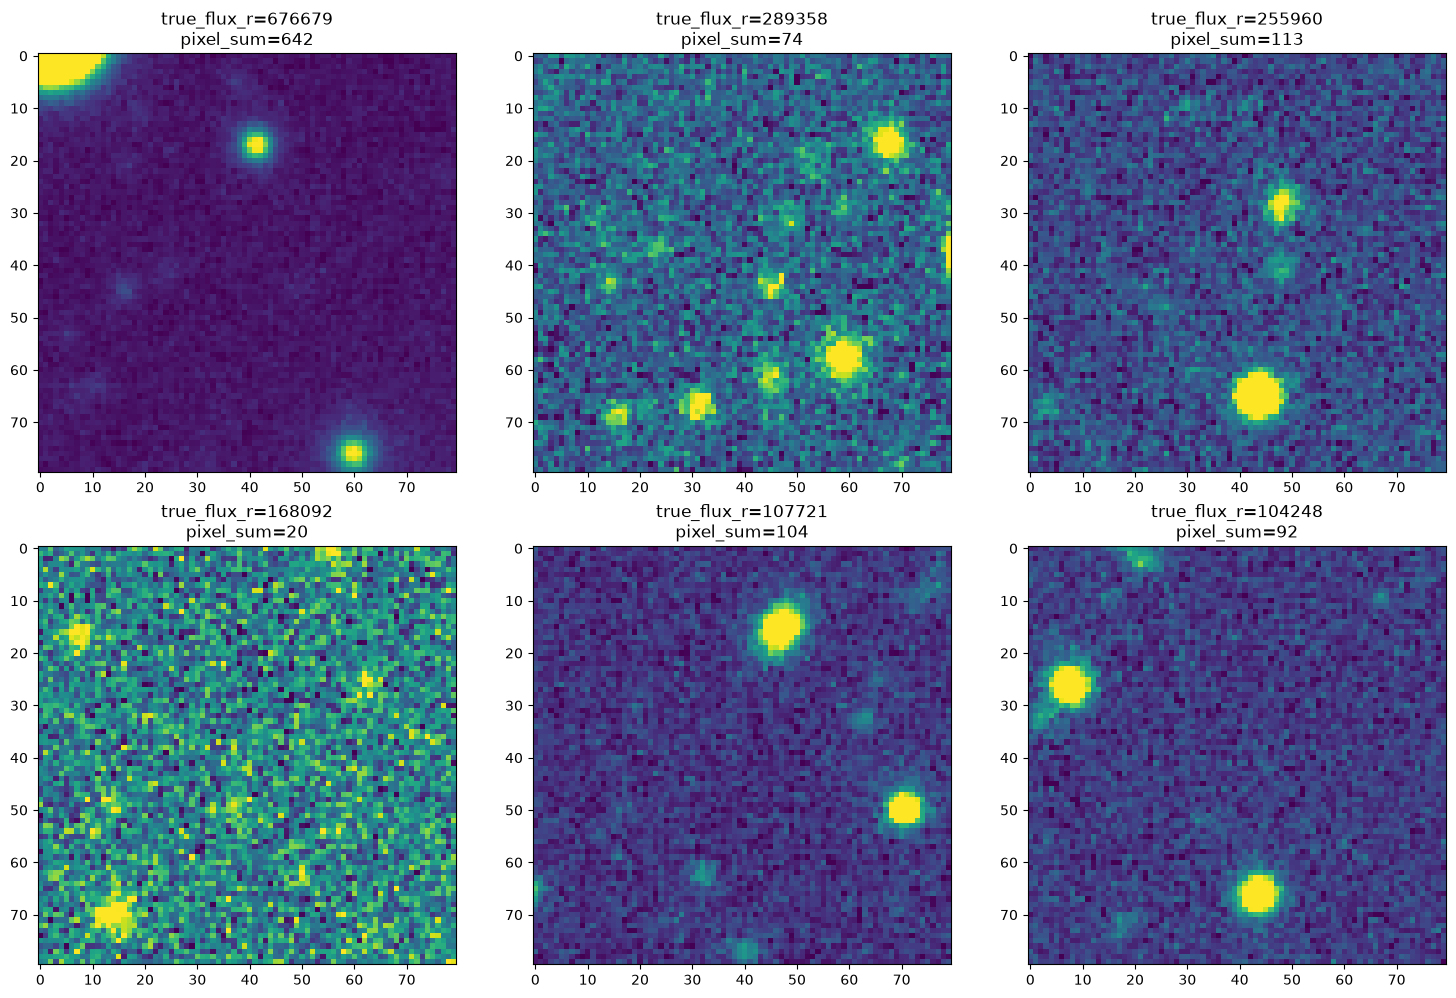

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Grab a few of the most extreme mismatches: high true flux, near-zero pixel sum
worst = calib_df.sort_values("true_flux_r", ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (_, row) in zip(axes.flat, worst.iterrows()):
    arr = np.load(row["tile_path"])
    ax.imshow(arr[r_band_index], vmin=np.percentile(arr[r_band_index], 1),
                                    vmax=np.percentile(arr[r_band_index], 99))
    ax.set_title(f"true_flux_r={row['true_flux_r']:.0f}\npixel_sum={row['pixel_sum_r']:.0f}")
plt.tight_layout()
plt.show()